> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# **IS 4487 LAB 11: Linear Regression for HR**

In this lab, we'll use an HR dataset to build a **linear regression model** to predict the number of years that an employee will work for the company (job tenure).


## Outline
1. Load and explore the dataset
2. Clean and prepare features
3. Encode categorical variables
4. Split the data into training and test sets
5. Train and evaluate a linear regression model
6. Reflect on variable importance and model fit




<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Labs/lab_11_regression.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# **Context: HR data**

## Problem Statement
A large company employs, at any given point of time, around 4000 employees. However, every year, around 15% of its employees leave the company and need to be replaced with the talent pool available in the job market. The management believes that this employee turnover is bad for the company, because of the following reasons -

- The former employees' projects get delayed, which makes it difficult to meet timelines, resulting in a reputation loss among consumers and partners
- A sizeable department has to be maintained, for the purposes of recruiting new talent
- More often than not, the new employees have to be trained for the job and/or given time to acclimatize themselves to the company

Hence, the management has contracted an HR analytics firm to understand what factors they should focus on, in order to increase the number of years that employees stay with the company. In other words, they want to know what changes they should make to their workplace, in order to get most of their employees to stay. Also, they want to know which of these variables is most important and needs to be addressed right away.

Since you are one of the star analysts at the analytics firm, this project has been given to you.

## Goal of the case study
You are required to model the number of years employees work for the company using a linear regression model. The results thus obtained will be used by the management to understand what changes they should make to their workplace, in order to get most of their employees to stay.


## Dataset Overview

**Dataset:** `merged_hr_data.csv`  
Source: [Kaggle HR Analytics Case Study](https://www.kaggle.com/datasets/vjchoudhary7/hr-analytics-case-study)

| Variable                      | Type        | Description |
|-------------------------------|-------------|-------------|
| `Age`                         | Numeric     | Age of the employee |
| `Attrition`                   | Categorical | Whether the employee has left the company (Yes/No) |
| `BusinessTravel`              | Categorical | Frequency of business travel |
| `Department`                  | Categorical | Department name |
| `DistanceFromHome`           | Numeric     | Distance from home to work (in km) |
| `Education`                  | Ordinal     | Employee education level (1–5) |
| `EducationField`             | Categorical | Field of education |
| `EmployeeCount`              | Constant    | Always 1 (not useful for modeling) |
| `EmployeeID`                 | Identifier  | Unique identifier for employee |
| `EnvironmentSatisfaction`    | Ordinal     | Satisfaction with the environment (1–4) |
| `Gender`                     | Categorical | Gender of the employee |
| `JobInvolvement`             | Ordinal     | Level of involvement with job (1–4) |
| `JobLevel`                   | Ordinal     | Employee level (1–5) |
| `JobRole`                    | Categorical | Job title |
| `JobSatisfaction`            | Ordinal     | Satisfaction with the job (1–4) |
| `MaritalStatus`              | Categorical | Marital status |
| `MonthlyIncome`              | Numeric     | Monthly salary in USD |
| `NumCompaniesWorked`         | Numeric     | Number of companies previously worked for |
| `Over18`                     | Constant    | Always "Y" (not useful) |
| `PercentSalaryHike`          | Numeric     | Percentage salary increase |
| `PerformanceRating`          | Ordinal     | Performance rating (1–4) |
| `StandardHours`              | Constant    | Always 8 (not useful) |
| `StockOptionLevel`           | Ordinal     | Stock options level (0–3) |
| `TotalWorkingYears`          | Numeric     | Total years of professional experience |
| `TrainingTimesLastYear`      | Numeric     | Number of training sessions attended last year |
| `WorkLifeBalance`            | Ordinal     | Work-life balance rating (1–4) |
| `YearsAtCompany`             | Numeric     | Years spent at the current company |
| `YearsSinceLastPromotion`    | Numeric     | Years since last promotion |
| `YearsWithCurrManager`       | Numeric     | Years with current manager |

**Target Variable:** `YearsAtCompany`

## **Part 1: Import packages, load and preview data**




In [3]:
import pandas as pd
import numpy as np

# Load the merged HR dataset
url = "https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/merged_hr_data.csv"
df = pd.read_csv(url)

# this is a wide dataset with many columns - increase display width to show all
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)


# Preview structure
print("Shape:", df.shape)
df.head()


Shape: (4410, 29)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.0,Y,11,8,0,1.0,6,1,0,0,3.0,4.0,2.0,3,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.0,Y,23,8,1,6.0,3,5,1,4,3.0,2.0,4.0,2,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.0,Y,15,8,3,5.0,2,5,0,3,2.0,2.0,1.0,3,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.0,Y,11,8,3,13.0,5,8,7,5,4.0,4.0,3.0,2,3
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.0,Y,12,8,2,9.0,2,6,0,4,4.0,1.0,3.0,3,3


## **Part 2: Data Cleaning**

Real-world HR data often contains administrative fields (e.g., ID numbers), constants (same value for all rows), or missing values.

### What We’re Doing:
- Remove irrelevant or constant columns: `EmployeeCount`, `Over18`, `StandardHours`, `EmployeeID`
- Drop rows with missing data

### Why It Matters:
- Non-informative or redundant features can reduce model accuracy and interpretability.
- Regression does not handle missing values natively, so we need a clean dataset.
- Dropping some rows is reasonable here due to the relatively small number of nulls.

> Ethical Note: In practice, dropping rows may disproportionately exclude certain groups—so this step should be handled with caution.


In [4]:
# Drop unnecessary columns
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeID', 'Attrition']
df.drop(columns=drop_cols, inplace=True)

# Drop rows with any missing values
df.dropna(inplace=True)

# Check result
print("After cleaning:", df.shape)


After cleaning: (4300, 24)


## **Part 3: Encode Categorical Variables**

### Nominal variables

Machine learning algorithms like linear regression require **numeric inputs**. To use nominal categorical data like `Gender` or `JobRole` (where order does not matter), we convert them into **dummy variables** using **one-hot encoding.**

Example:
Colors   |  col_Blue | col_Green  | col_Red    |
|--------|-------|--------|--------|
Blue     |   1   | 0      | 0      |
Green    |  0    | 1      | 0      |
Red      | 0     | 0      | 1      |

When a categorical variable is dummy coded, we should drop (any) one of the dummy variables in order to prevent **multicollinearity** which occurs when one of the column is a perfect linear combination of one or more other columns in the data. The Colors column is perfectly described by the sum of the three dummy columns.

This is perfect multicollinearity—the model cannot uniquely estimate the coefficients because the columns are perfectly redundant.

> SOLUTION: drop one dummy coded column.

### Ordinal/ ordered variables

Ordered variables should be integer encoded to make them numeric. For example, Education, JobInvolvement, JobLevel and others that are ordinal are already integer coded in this dataset, so we do not need to do anything more. These variables will be treated like numeric data.


### Key Steps:
- first **integer encode** all ordinal columns and drop the original ordinal variable if present. In our data, this step has already been done. Else, you can use sklearn's `OrdinalEncoder` to fit and transform data
- second, perform **dummy variable encoding** using  `pd.get_dummies()` with `drop_first=True` to avoid multicollinearity. This function will convert all categorical columns (in our data all of which are nominal), into dummy variables.

### Why It Matters:
- Ensures model can interpret nominal categorical inputs numerically
- Dropping the first dummy prevents the **dummy variable trap** where one variable is a linear combination of others

> Reminder: Avoid encoding identifiers or columns with too many unique levels without reduction. Identifiers have no menainful relationship with outcomes. Too many dummy variables created due to having too many values in a caegorical variable will lead us to the other problem of **overfitting**



In [5]:
# One-hot encode all categorical features (here ones remaining are all nominal)
df_encoded = pd.get_dummies(df, drop_first=True)

# Preview encoded columns
display(df_encoded.head())
df_encoded.info()

,Age,DistanceFromHome,Education,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,51,6,2,1,131160,1.0,11,0,1.0,6,1,0,0,3.0,4.0,2.0,3,3,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,31,10,1,1,41890,0.0,23,1,6.0,3,5,1,4,3.0,2.0,4.0,2,4,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True
2,32,17,4,4,193280,1.0,15,3,5.0,2,5,0,3,2.0,2.0,1.0,3,3,True,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False
3,38,2,5,3,83210,3.0,11,3,13.0,5,8,7,5,4.0,4.0,3.0,2,3,False,False,True,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False
4,32,10,1,1,23420,4.0,12,2,9.0,2,6,0,4,4.0,1.0,3.0,3,3,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,True


<class 'pandas.core.frame.DataFrame'>
Index: 4300 entries, 0 to 4408
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                4300 non-null   int64  
 1   DistanceFromHome                   4300 non-null   int64  
 2   Education                          4300 non-null   int64  
 3   JobLevel                           4300 non-null   int64  
 4   MonthlyIncome                      4300 non-null   int64  
 5   NumCompaniesWorked                 4300 non-null   float64
 6   PercentSalaryHike                  4300 non-null   int64  
 7   StockOptionLevel                   4300 non-null   int64  
 8   TotalWorkingYears                  4300 non-null   float64
 9   TrainingTimesLastYear              4300 non-null   int64  
 10  YearsAtCompany                     4300 non-null   int64  
 11  YearsSinceLastPromotion            4300 non-null   int64  
 1

### **🔧 Try It Yourself - Part 3**

3.1. How many new columns were created during one-hot encoding?  you can compare the shape of the two dataframes in the outputs above.

3.2. Why is it important to avoid including columns like `EmployeeID` as a feature in predictive modeling?

3.3. Our model is trying to predict employment longevity.  Why is `Attrition` problematic for predicting years at the company?

Write a few sentences on each of the questions above. No coding is required here.


🔧 3.1 Add comment here:


🔧 3.2 Add comment here:


🔧 3.3 Add comment here:





### **Part 4: Standardizing Features for Regression**

When using models like **linear regression**, it's highly recommended to ensure all numeric features are on a similar scale. This helps the model converge more reliably and prevents features with larger magnitudes from dominating the learning process.

#### What data types to standardize?
- continuous: YES
- ordinal variables that are integer encoded: YES
- nominal categorical that are dummy coded/one-hot encoded: NO
- target variable: NO

In this step, we'll use `StandardScaler` from `sklearn` to scale all nuemric (continuous and integer-encoded feature) columns to have a mean of 0 and a standard deviation of 1. We do not scale the categorical features, as it would make their interpretation difficult.

This is especially important if your dataset includes variables with vastly different units or scales (e.g., "Age" vs. "MonthlyIncome")

> **Note:** The target variable (`YearsAtCompany`) should **not** be scaled — only the continuous input features.

---


In [6]:
from sklearn.preprocessing import StandardScaler

# Separate the features and the target
X_unscaled = df_encoded.drop(columns=['YearsAtCompany'])
y = df_encoded['YearsAtCompany']

# Identify columns that are truly continuous numeric features (excluding the target variable 'YearsAtCompany')
X_needs_scaling = X_unscaled.select_dtypes(include=['int', 'float'])

# Apply standardization to the continuous features (leave out all categorical encoded features)
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_needs_scaling)

# Reconstruct scaled DataFrame from the output of StandardScaler
X_numeric_scaled_df = pd.DataFrame(X_numeric_scaled, columns=X_needs_scaling.columns, index=df_encoded.index)

# combine this above DF with the DF of boolean columns selected from X_unscaled
X_boolean = X_unscaled.select_dtypes(include=['bool'])
X = pd.concat([X_numeric_scaled_df, X_boolean], axis=1)

# Preview the final set of features
X.head()

,Age,DistanceFromHome,Education,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,1.538800,-0.394993,-0.891282,-0.964277,1.405193,-0.677226,-1.149725,-0.931939,-1.320442,2.483520,-0.677926,-1.159067,0.252403,1.157359,-1.075518,0.38155,-0.426577,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,-0.648079,0.099071,-1.867220,-0.964277,-0.492557,-1.077952,2.126858,0.239797,-0.678523,0.157924,-0.368371,-0.037179,0.252403,-0.657940,1.750469,-1.02554,2.344242,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True
2,-0.538735,0.963683,1.060595,1.746964,2.725773,-0.677226,-0.057531,2.583269,-0.806907,-0.617274,-0.677926,-0.317651,-0.661946,-0.657940,-2.488512,0.38155,-0.426577,True,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False
3,0.117329,-0.889057,2.036534,0.843217,0.385846,0.124225,-1.149725,2.583269,0.220163,1.708321,1.488960,0.243293,1.166752,1.157359,0.337475,-1.02554,-0.426577,False,False,True,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False
4,-0.538735,0.099071,-1.867220,-0.964277,-0.885202,0.524950,-0.876677,1.411533,-0.293372,-0.617274,-0.677926,-0.037179,1.166752,-1.565590,0.337475,0.38155,-0.426577,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,True


### **🔧 Try It Yourself - Part 4**

You've now scaled your features using `StandardScaler`, which makes each feature have a mean of 0 and a standard deviation of 1.

**Think about this:**
Suppose we didn't standardize the features and trained a regression model using raw input data instead. What might happen to the interpretation or relative importance of the coefficients?

4.1 Write one or two sentences explaining how not standardizing the data could affect the model's performance or interpretability.


🔧 4.1 Add comment here:

## **Part 5: Train-Test Split**

We'll split the dataset into:
- 80% for training
- 20% for testing



In [7]:
from sklearn.model_selection import train_test_split

# Use already standardized features in X, and original target y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the splits
X_train.shape, X_test.shape



((3440, 37), (860, 37))

### **🔧 Try It Yourself - Part 5**

5.1. In the code cell below, calculate what average `YearsAtCompany` is for all employees


In [8]:
# 🔧 5.1 Add code here
df['YearsAtCompany'].mean()


np.float64(7.026046511627907)

## **Part 6: Train the Regression**

Now we fit a linear regression model using the training data.  

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Display coefficients in order of highest to lowest correlation
coefficients_linear = pd.Series(linear_model.coef_, index=X.columns)
print("\nLinear Regression Coefficients (ordered):")
print(coefficients_linear.sort_values(ascending=False))



Linear Regression Coefficients (ordered):
YearsWithCurrManager                 2.826632
TotalWorkingYears                    2.474845
YearsSinceLastPromotion              1.435622
JobRole_Manager                      0.655916
Department_Research & Development    0.469019
JobRole_Human Resources              0.315735
JobRole_Research Director            0.300285
Department_Sales                     0.299194
PercentSalaryHike                    0.081811
DistanceFromHome                     0.074295
JobInvolvement                       0.060203
EnvironmentSatisfaction              0.055572
JobSatisfaction                      0.045605
JobRole_Manufacturing Director       0.033466
TrainingTimesLastYear                0.010814
StockOptionLevel                     0.008534
WorkLifeBalance                      0.001934
Education                           -0.033129
JobRole_Research Scientist          -0.057945
JobLevel                            -0.062545
MaritalStatus_Married               -

### **🔧 Try It Yourself - Part 6**

Write a few sentences on each of the questions below. No coding is required here.

6.1. Which features are most positively associated with high job tenure (years at company)?

6.2. Which features are most negatively associated with staying?




🔧 6.1. Add commment here


🔧 6.2. Add commment here



## **Part 7: Evaluate Model Performance**

Let's test how well our model generalizes to unseen data. We'll compute:
- Mean Squared Error (MSE)
- R-Squared

In [10]:
# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred_linear)
r2 = r2_score(y_test, y_pred_linear)

# Print the evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 9.22
R-squared (R2): 0.76


Now visualize the model output

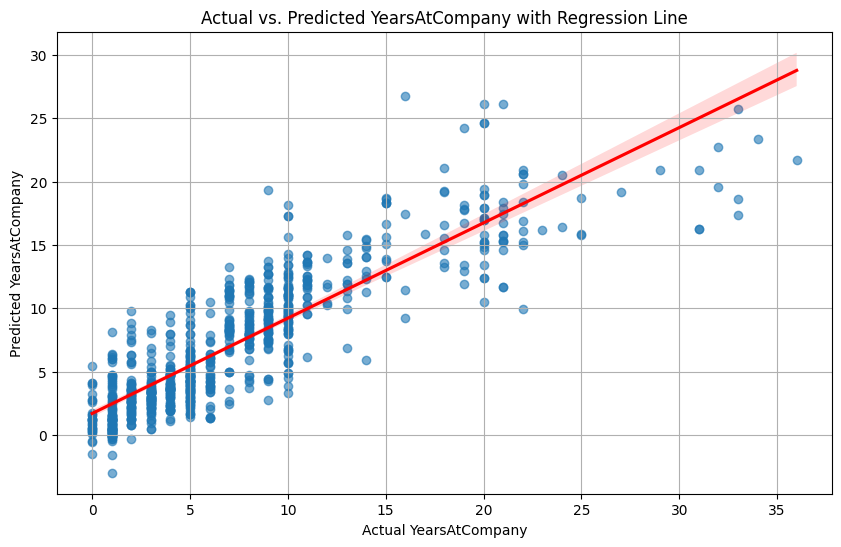

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of predicted vs actual YearsAtCompany
plt.figure(figsize=(10, 6))
ax = sns.regplot(x=y_test, y=y_pred_linear, scatter_kws={'alpha':0.6}, line_kws={"color": "red"})
ax.set_xlabel("Actual YearsAtCompany")
ax.set_ylabel("Predicted YearsAtCompany")
plt.title("Actual vs. Predicted YearsAtCompany with Regression Line")
plt.grid(True)
plt.show()

### **🔧 Try It Yourself - Part 7**

7.1. Is this R-squared fit good?

7.2. How could we improve the fit?

🔧 7.1. Add your comment here


🔧 7.2. Add your comment here

## **Part 8: Feature Selection for Performance Improvement**

Not all features equally influence `YearsAtCompany`. By identifying and using only the most important predictors, we can:
- Simplify the model, which **reduces overfitting**
- trade less variance for slightly more bias (recall **bias-variance tradeoff**)
- Potentially improve performance or interpretability


We'll use the linear regression model's coefficients to rank feature importance. To do so, we will use their absolute values (because we care about the magnitude of the coefficient, be it positive or negative).


In [12]:
# Get the top 10 features based on the absolute coefficient magnitude
top_10_feature_names = coefficients_linear.abs().sort_values(ascending=False).head(10).index

# Print the actual coefficient values for these top 10 features
print("Top 10 features by absolute coefficient magnitude (with actual values):")
display(coefficients_linear.loc[top_10_feature_names])

Top 10 features by absolute coefficient magnitude (with actual values):


,0
YearsWithCurrManager,2.826632
TotalWorkingYears,2.474845
YearsSinceLastPromotion,1.435622
EducationField_Medical,-0.929562
NumCompaniesWorked,-0.856354
EducationField_Technical Degree,-0.730991
EducationField_Life Sciences,-0.724575
JobRole_Manager,0.655916
Department_Research & Development,0.469019
EducationField_Marketing,-0.434769


### **🔧 Try It Yourself - Part 8**

Write the following code:

8.1. Create a new training and test set using only the 10 most important features.

8.2. Retrain the linear regression model on this reduced dataset.

8.3. Use the new model to predict on the test set

8.4. Evaluate performance of the new version


In [13]:
# 🔧 8.1: Create new versions of X_train and X_test with only those top features

X_reduced = X[top_10_feature_names]
X_reduced_train, X_reduced_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
X_reduced_train.shape, X_reduced_test.shape

# 🔧 8.2: Initialize and fit a new Regression model on the reduced feature set
linear_model_reduced = LinearRegression()
linear_model_reduced.fit(X_reduced_train, y_train)

# 🔧 8.3: Use the new model to predict on the test set
y_pred_reduced = linear_model_reduced.predict(X_reduced_test)

# 🔧 8.4: Evaluate the reduced model using R-squared
mse = mean_squared_error(y_test, y_pred_reduced)
r2 = r2_score(y_test, y_pred_reduced)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 9.34
R-squared (R2): 0.75


Write a few sentences on each of the questions below. No coding is required here.

🔧 8.4. How did the reduced-feature model compare to the full model?

🔧 8.5. Would this version be easier to explain or use in an HR meeting?



🔧 8.4. Add your comment here

🔧 8.5. Add your comment here

## **Part 9: Regularization**

We can use built-in techniques to reduce model complexity called **regularization** without having to arbitrarily choose the top x coefficients to keep.

- **Lasso regression**:
    - Adds an L1 penalty: the sum of absolute values of coefficients.
    - Can shrink coefficients exactly to zero → performs feature selection.
    - Good when you expect only a few features to matter.
    - controlled using *hyperparameter* `alpha` (higher alpha = greater regularization, simpler model)
- **Ridge regression**
    - Adds an L2 penalty: the sum of squared coefficients.
    - Shrinks coefficients toward zero but never exactly to zero.
    - Useful when features are correlated; stabilizes the model.
    - controlled using *hyperparameter* `alpha` (higher alpha = greater regularization, simpler model)

### How to select the hyperparameter alpha?
- we would have to manually try different values, generally we can start by trying powers of 10, then powers of 2 etc. `alpha = 1` equals no regularization.
- OR we can use `LassoCV` or `RidgeCV`, two classes that perform crossvalidation. They will try several values in a specified range to automatically find the best alpha.

Below we will run LassoCV.

In [14]:
from sklearn.linear_model import LassoCV

# Initialize and train the LassoCV Regression model
lasso_model = LassoCV(alphas=np.logspace(-4, 4, 100), cv=5)
lasso_model.fit(X_train, y_train)

# Best alpha found
print("Best alpha:", lasso_model.alpha_)

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate the model
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"\nLasso Regression Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Lasso Regression R-squared (R2): {r2_lasso:.2f}")

# Display Lasso Coefficients to see which ones were kept
coefficients_lasso = pd.Series(lasso_model.coef_, index=X.columns)
print("\nLasso Regression Coefficients (ordered by absolute value, descending):")
print(coefficients_lasso.loc[coefficients_lasso.abs().sort_values(ascending=False).index])


Best alpha: 0.018307382802953697

Lasso Regression Mean Squared Error (MSE): 9.19
Lasso Regression R-squared (R2): 0.76

Lasso Regression Coefficients (ordered by absolute value, descending):
YearsWithCurrManager                 2.816071
TotalWorkingYears                    2.417382
YearsSinceLastPromotion              1.439566
NumCompaniesWorked                  -0.824123
JobRole_Manager                      0.407047
Age                                 -0.367117
EducationField_Other                 0.289082
EducationField_Medical              -0.185289
Gender_Male                         -0.097375
MonthlyIncome                       -0.071276
DistanceFromHome                     0.057031
BusinessTravel_Travel_Rarely        -0.056363
JobLevel                            -0.044267
JobInvolvement                       0.040685
EnvironmentSatisfaction              0.039988
JobRole_Sales Executive             -0.034098
JobSatisfaction                      0.031825
Department_Research & Deve

### **🔧 Try It Yourself - Part 9**

Now try to write code for RidgeCV.
All you have to do is change LassoCV to RidgeCV and rename appropriate variables to indicate that they are for ridge rather than lasso.


9.1. Import RidgeCV from sklearn.linear_model

9.2. Initialize and train the RidgeCV Regression model. set a range of alpha values to try. Set cv to 5

9.3. Print the best alpha value found

9.4. Make predictions on the test set

9.5. Evaluate the model on the test set



In [15]:
# 🔧 9.1 import
from sklearn.linear_model import RidgeCV

# 🔧 9.2 Initialize and train the RidgeCV Regression model
ridge_model = RidgeCV(alphas=np.logspace(-4, 4, 100), cv=5)
ridge_model.fit(X_train, y_train)

# 🔧 9.3 Best alpha found
print("Best alpha:", ridge_model.alpha_)

# 🔧 9.4 Make predictions on the test set
y_pred_ridge = ridge_model.predict(X_test)

# 🔧 9.5 Evaluate the model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"\nLasso Regression Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Lasso Regression R-squared (R2): {r2_ridge:.2f}")

# Display Lasso Coefficients
coefficients_ridge = pd.Series(ridge_model.coef_, index=X.columns)
print("\nRidge Regression Coefficients (ordered by absolute value, descending):")
print(coefficients_ridge.loc[coefficients_ridge.abs().sort_values(ascending=False).index])

Best alpha: 65.79332246575683

Lasso Regression Mean Squared Error (MSE): 9.20
Lasso Regression R-squared (R2): 0.76

Ridge Regression Coefficients (ordered by absolute value, descending):
YearsWithCurrManager                 2.791287
TotalWorkingYears                    2.393404
YearsSinceLastPromotion              1.446431
NumCompaniesWorked                  -0.839398
JobRole_Manager                      0.475408
EducationField_Medical              -0.359543
Age                                 -0.350579
EducationField_Other                 0.340723
BusinessTravel_Travel_Rarely        -0.200945
JobRole_Research Director            0.185355
JobRole_Human Resources              0.171895
Department_Research & Development    0.170588
JobRole_Sales Executive             -0.163210
EducationField_Life Sciences        -0.161882
Gender_Male                         -0.159451
EducationField_Technical Degree     -0.149380
JobRole_Laboratory Technician       -0.146526
BusinessTravel_Travel_Frequen

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [18]:
!jupyter nbconvert --to html "SOLN_lab_11_regression.ipynb"

[NbConvertApp] Converting notebook SOLN_lab_11_regression.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 494442 bytes to SOLN_lab_11_regression.html
